# Global Air Quality Analysis: Trends, Hotspots, and PM2.5 Prediction

## Project Overview
This analysis examines air quality patterns across countries and cities using pollutant and weather indicators. The workflow includes:
- data cleaning and structure checks
- feature engineering from the date column
- PM2.5 severity categorization
- hotspot analysis by city and country
- seasonal and monthly trend analysis
- city segmentation with clustering
- baseline modeling for PM2.5 prediction

## Project Questions
1. Which cities and countries have the highest average PM2.5 levels in this dataset?
2. How does PM2.5 vary across months and seasons?
3. Can cities be grouped into segments using pollutant and weather patterns?
4. Can PM2.5 be predicted reasonably well from other available variables? 

In [30]:
# Import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#Show all columns when previewing tables
pd.set_option('display.max_columns', None)

In [31]:
#Load the air quality dataset
df=pd.read_csv("global_air_quality.csv")
df.head()

,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
0,Bangkok,Thailand,3/19/2023,86.57,25.19,99.88,30.63,4.46,36.29,17.67,59.35,13.76
1,Istanbul,Turkey,2/16/2023,50.63,97.39,48.14,8.71,3.40,144.16,3.46,67.51,6.36
2,Rio de Janeiro,Brazil,11/13/2023,130.21,57.22,98.51,9.92,0.12,179.31,25.29,29.30,12.87
3,Mumbai,India,3/16/2023,119.70,130.52,10.96,33.03,7.74,38.65,23.15,99.97,7.71
4,Paris,France,4/4/2023,55.20,36.62,76.85,21.85,2.00,67.09,16.02,90.28,14.16


# Data Overview and Cleaning

In [41]:
# Perform initial data inspectionprint("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isna().sum())

# Convert the Date column into datetime format
# errors='coerce' safely converts invalid values to NaT
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Create time-based features for trend analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.month_name()
df['Quarter'] = df['Date'].dt.quarter

# Create a helper function to group months into seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

# Apply the season mapping to each record
df['Season'] = df['Month'].apply(get_season)

# Create PM2.5 air quality categories based on standard threshold ranges
def pm25_category(x):
    if x <= 12:
        return 'Good'
    elif x <= 35.4:
        return 'Moderate'
    elif x <= 55.4:
        return 'Unhealthy for Sensitive Groups'
    elif x <= 150.4:
        return 'Unhealthy'
    elif x <= 250.4:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

# Assign each PM2.5 observation to a severity category
df['PM25_Category'] = df['PM2.5'].apply(pm25_category)

# Build a compact summary table to understand dataset coverage
summary = {
    'Rows': len(df),
    'Countries': df['Country'].nunique(),
    'Cities': df['City'].nunique(),
    'Date range start': df['Date'].min().date(),
    'Date range end': df['Date'].max().date(),
    'Average PM2.5': round(df['PM2.5'].mean(), 2),
    'Median PM2.5': round(df['PM2.5'].median(), 2)
}

# Display the summary statistics
summary



Columns:
['City', 'Country', 'Date', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Temperature', 'Humidity', 'Wind Speed', 'Year', 'Month', 'MonthName', 'Quarter', 'Season', 'PM25_Category']

Missing values:
City             0
Country          0
Date             0
PM2.5            0
PM10             0
NO2              0
SO2              0
CO               0
O3               0
Temperature      0
Humidity         0
Wind Speed       0
Year             0
Month            0
MonthName        0
Quarter          0
Season           0
PM25_Category    0
dtype: int64


{'Rows': 10000,
 'Countries': 19,
 'Cities': 20,
 'Date range start': datetime.date(2023, 1, 1),
 'Date range end': datetime.date(2023, 12, 28),
 'Average PM2.5': np.float64(77.45),
 'Median PM2.5': 77.72}

### Cleaning summary

The dataset contains **10,000 rows**, **19 countries**, and **20 cities**, covering the period from **2023-01-01** to **2023-12-28**.

The average PM2.5 level is **77.45**, and the median is **77.72**, which shows the values are centered in a fairly narrow range. Date-based fields were added so the data could be analyzed by month, quarter, and season.

**What this means:** the dataset is large enough for pattern-finding, but the tight spread in PM2.5 suggests we should expect moderate differences rather than dramatic shifts across time or location.

# PM2.5 Severity Distribution

In [42]:
# Analyze the distribution of PM2.5 severity categories
# Count how many observations fall into each air quality category.

category_counts = df['PM25_Category'].value_counts().sort_values(ascending=False)

# Display the counts in table form
category_counts

PM25_Category
Unhealthy                         6504
Moderate                          1610
Unhealthy for Sensitive Groups    1389
Good                               497
Name: count, dtype: int64

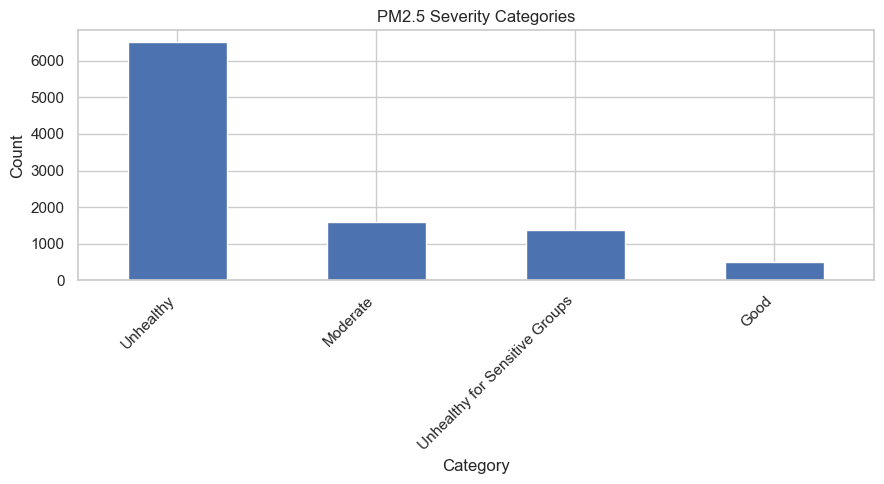

In [43]:
# Visualize PM2.5 severity categories
# Create a bar chart to show how frequently each PM2.5 category appears.

plt.figure(figsize=(9,5))
category_counts.plot(kind='bar')
plt.title('PM2.5 Severity Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Most observations fall into the **Unhealthy** category.

- Good: **497**
- Moderate: **1,610**
- Unhealthy for Sensitive Groups: **1,389**
- Unhealthy: **6,504**
- Very Unhealthy: **0**
- Hazardous: **0**

**What this means:** the distribution is heavily concentrated in one band. This makes the main takeaway clear. In this dataset, poor air quality is common, while the cleanest and most extreme conditions are much less frequent.

# Hotspot analysis by city and country

In [57]:
# Identify pollution hotspots by city and country
# Group the data to calculate average PM2.5 levels at both the city and country level. This helps identify the highest-pollution locations in the dataset.

top_cities = df.groupby('City')['PM2.5'].mean().sort_values(ascending=False).round(2)
top_countries = df.groupby('Country')['PM2.5'].mean().sort_values(ascending=False).round(2)

print('Top cities by average PM2.5:')
display(top_cities.head(10))

print('\nTop countries by average PM2.5:')
display(top_countries.head(10))   

Top cities by average PM2.5:


City
Dubai          80.01
Sydney         78.93
Mumbai         78.90
Tokyo          78.87
Mexico City    78.86
Beijing        78.63
Moscow         77.88
New York       77.86
Toronto        77.83
Istanbul       77.71
Name: PM2.5, dtype: float64


Top countries by average PM2.5:


Country
UAE             80.01
Australia       78.93
India           78.90
Japan           78.87
Mexico          78.86
China           78.63
Russia          77.88
Canada          77.83
Turkey          77.71
South Africa    77.67
Name: PM2.5, dtype: float64

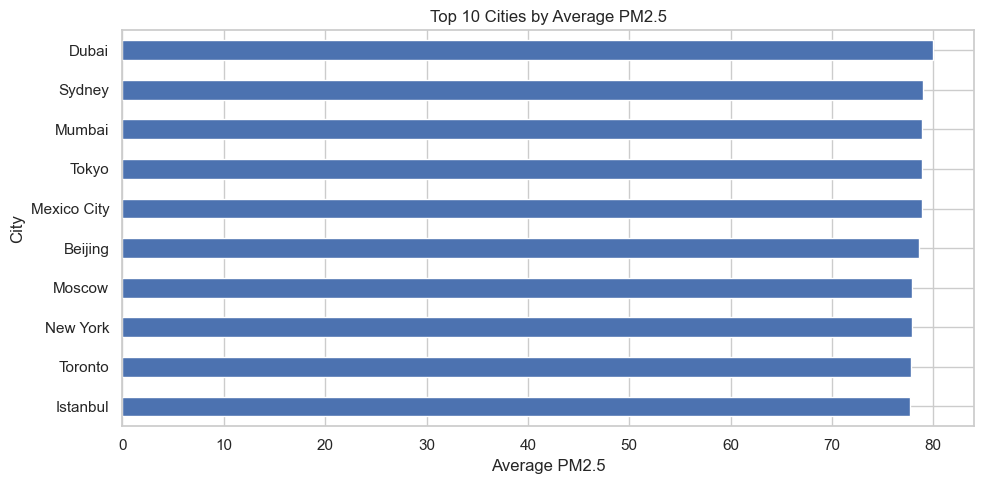

In [55]:
# 6. Visualize the top polluted cities

plt.figure(figsize=(10,5))
top_cities.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Cities by Average PM2.5')
plt.xlabel('Average PM2.5')
plt.ylabel('City')
plt.tight_layout()
plt.show()
             

The cities with the highest average PM2.5 values in this dataset are **Dubai (80.01), Sydney (78.93), Mumbai (78.90), Tokyo (78.87), Mexico City (78.86)**.

**What this means:** the differences between the top cities are small, so this chart is more useful for ranking locations than claiming major gaps in pollution levels. It helps identify where PM2.5 tends to be relatively higher within this dataset.

# Monthly and Seasonal Patterns

In [46]:
# Explore monthly and seasonal PM2.5 trends
# Reorder months manually so they appear in calendar order instead of alphabetical order.

month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']

# Calculate average PM2.5 by month and season
monthly_pm25 = df.groupby('MonthName')['PM2.5'].mean().reindex(month_order).round(2)
seasonal_pm25 = df.groupby('Season')['PM2.5'].mean().round(2)

# Display both summaries
display(monthly_pm25)
display(seasonal_pm25)

MonthName
January      79.47
February     76.45
March        78.50
April        76.75
May          76.49
June         76.58
July         76.64
August       79.26
September    74.44
October      77.66
November     78.61
December     78.74
Name: PM2.5, dtype: float64

Season
Fall      76.89
Spring    77.25
Summer    77.47
Winter    78.19
Name: PM2.5, dtype: float64

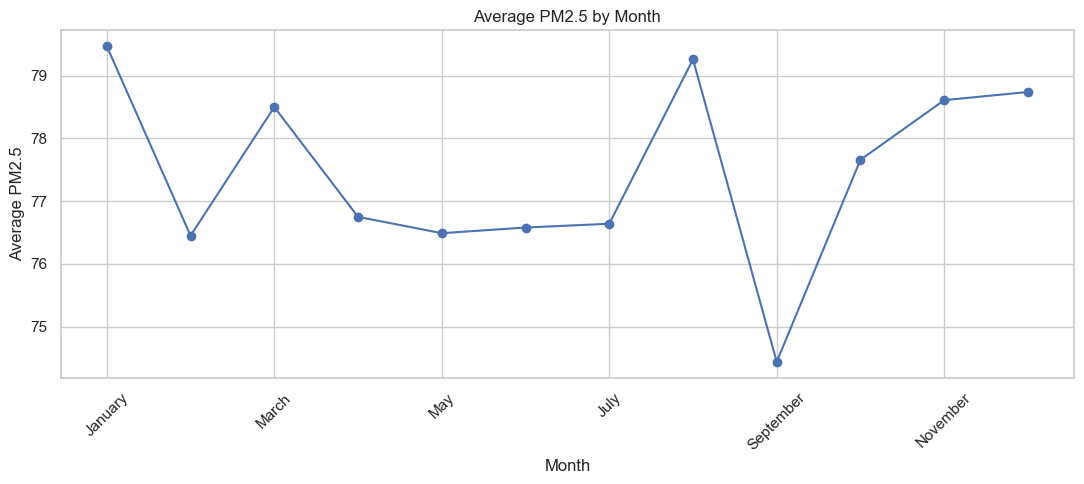

In [47]:
# Visualize monthly PM2.5 trend
# Plot the month-by-month average PM2.5 values to look for broad seasonal movement across the year.

plt.figure(figsize=(11,5))
monthly_pm25.plot(marker='o')
plt.title('Average PM2.5 by Month')
plt.xlabel('Month')
plt.ylabel('Average PM2.5')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The highest average PM2.5 months are:
- **January: 79.47**
- **August: 79.26**
- **December: 78.74**

The monthly variation is mild, which suggests limited seasonality in the dataset.


# Correlation Analysis

In [49]:
# 9. Measure relationships among pollutants and weather variables
# Build a correlation matrix to see whether PM2.5 moves together with other pollutants or weather-related features.

corr = df[['PM2.5','PM10','NO2','SO2','CO','O3','Temperature','Humidity','Wind Speed']].corr()

# Display the variables most correlated with PM2.5
corr['PM2.5'].sort_values(ascending=False)

PM2.5          1.000000
PM10           0.011353
O3             0.007570
CO             0.005891
NO2            0.004976
Humidity      -0.000947
Wind Speed    -0.001770
Temperature   -0.011945
SO2           -0.012547
Name: PM2.5, dtype: float64

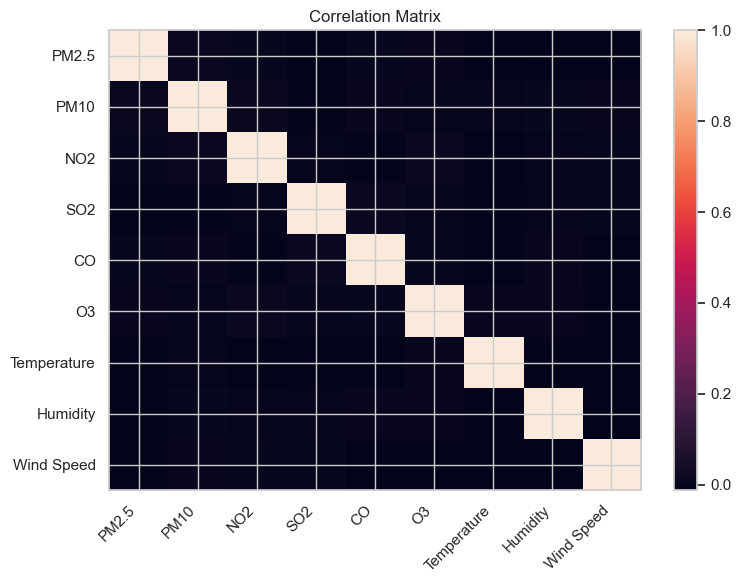

In [50]:
# Visualize the full correlation matrix
# A heatmap-style view makes it easier to compare the strength and direction of relationships across all variables.

plt.figure(figsize=(8,6))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

PM2.5 has very weak correlations with the other available features.

- PM10: **0.0114**
- O3: **0.0076**
- CO: **0.0059**
- NO2: **0.0050**
- Humidity: **-0.0009**
- Wind Speed: **-0.0018**
- Temperature: **-0.0119**
- SO2: **-0.0125**

**What this means:** none of the variables move closely with PM2.5.

# City segmentation with clustering

In [51]:
# Cluster cities based on pollution and weather profiles
# First, average the variables by city so that each city has one profile.
# Then standardize the values because the variables are measured on different scales. Finally, use K-Means to segment cities into clusters.

city_profiles = df.groupby('City')[['PM2.5','PM10','NO2','SO2','CO','O3','Temperature','Humidity','Wind Speed']].mean()

# Standardize the features before clustering
scaler = StandardScaler()
city_scaled = scaler.fit_transform(city_profiles)

# Fit K-Means with 3 clusters for a simple segmentation view
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
city_profiles['Cluster'] = kmeans.fit_predict(city_scaled)

# Display city-to-cluster assignments
city_profiles[['Cluster']].sort_values('Cluster')

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Cluster
City,
Bangkok,0
Beijing,0
Cairo,0
Dubai,0
Istanbul,0
Mexico City,0
New York,0
Sydney,0
Rio de Janeiro,1


In [52]:
# Summarize the characteristics of each cluster
# This table helps interpret how the city groups differ from one another.

cluster_summary = city_profiles.groupby('Cluster').mean().round(2)

# Display average pollutant and weather levels per cluster
cluster_summary

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
Cluster,,,,,,,,,
0,78.29,103.50,51.53,25.38,5.11,105.52,14.73,55.25,10.25
1,76.15,104.72,52.40,24.87,4.93,106.12,15.34,55.31,10.24
2,77.95,105.50,52.94,25.99,5.13,106.73,14.55,54.52,10.19


This clustering section adds an unsupervised learning component and shows how cities can be grouped by average pollutant and weather profiles.

**What this means:** clustering helps segment cities into similar profile groups, even when there is no target variable. In this project, the clusters are useful for comparison, but the profiles are still quite close to each other, so the separation is modest rather than dramatic.

# Baseline Machine Learning Model

In [56]:
#Build a baseline model to predict PM2.5
# This section uses a Random Forest Regressor to estimate PM2.5 based on other pollutants, weather variables, and time features.

# Select predictor variables
features = ['PM10','NO2','SO2','CO','O3','Temperature','Humidity','Wind Speed','Month','Quarter']
X = df[features]

# Define the target variable
y = df['PM2.5']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Generate predictions on the test set
pred = rf.predict(X_test)

# Evaluate model performance using common regression metrics
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print('MAE:', round(mae, 2))
print('RMSE:', round(rmse, 2))
print('R2:', round(r2, 3))

# Extract feature importance scores to see which predictors contributed the most to the model
feature_importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

# Display feature importance values
feature_importance

MAE: 36.24
RMSE: 42.38
R2: -0.025


Humidity       0.119191
SO2            0.117683
O3             0.117559
PM10           0.117179
Temperature    0.116507
NO2            0.116473
Wind Speed     0.116235
CO             0.115148
Month          0.051038
Quarter        0.012987
dtype: float64

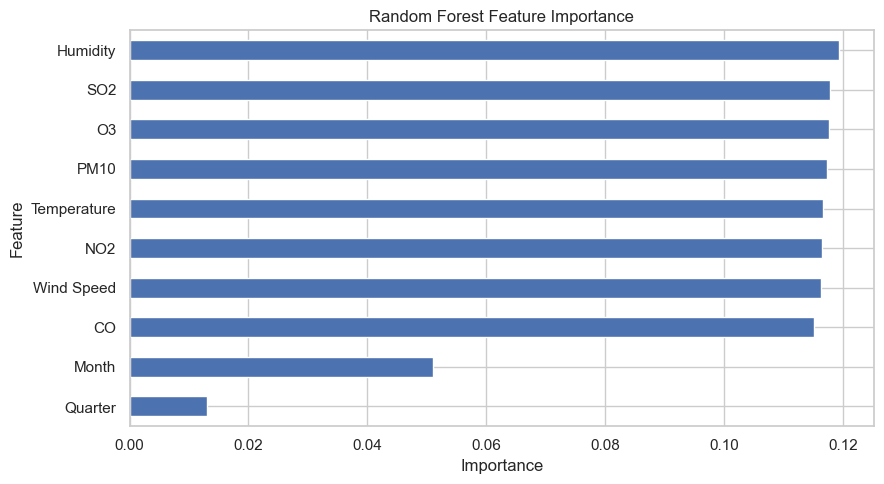

In [54]:
# Visualize feature importance from the Random Forest model
# This chart highlights which input variables the model relied on most when predicting PM2.5 values.

plt.figure(figsize=(9,5))
feature_importance.sort_values().plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The baseline Random Forest model produced:
- **MAE: 36.24**
- **RMSE: 42.38**
- **R²: -0.025**

**What this means:** the model does not explain PM2.5 well. A negative R² shows that the predictors add very little useful signal and perform worse than a simple average-based baseline. This supports the earlier finding that the relationships in the dataset are weak.

# Key findings

1. The dataset includes **10,000 records** across **19 countries** and **20 cities**.
2. The average PM2.5 level is **77.45**, and the median is **77.72**, showing a fairly tight overall spread.
3. Most observations are classified as **Unhealthy**, so poor air quality dominates the distribution.
4. The top cities by average PM2.5 are **Dubai, Sydney, Mumbai, Tokyo, and Mexico City**, but the gap between them is small.
5. Month-to-month variation exists, but it is limited, which points to weak seasonality.
6. Correlations between PM2.5 and the other variables are extremely weak, so none of the predictors stand out as strong drivers.
7. Clustering adds a useful segmentation view, but the city groups are still fairly similar overall.
8. The baseline model performs poorly, which is consistent with the weak relationships seen in the correlation analysis.

# Limitations

This dataset has several limitations that affect how the results should be interpreted:
- The data appears synthetic or randomly generated rather than naturally observed.
- Relationships between pollutants, weather variables, and PM2.5 are unusually weak.
- Model performance is limited because the predictors do not contain strong signal.
- The results are better interpreted as a structured analytical exercise than as strong environmental evidence.

# Coclusion

This analysis goes beyond simple exploratory charts by combining engineered features, severity categorization, geographic comparison, temporal analysis, clustering, model evaluation, and a clear discussion of limitations.

**Key takeaway:** the strongest part of this project is the analytical workflow and the disciplined interpretation of results. The data supports a structured evaluation of patterns, while the weak model performance shows that not every dataset contains strong predictive signal.
